## Company Data

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import  DecisionTreeClassifier
from sklearn import tree
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder

In [2]:
# Import dataset
company = pd.read_csv('E:\Assignment\Assignment 14 - Dicision tree\Company_Data.csv')
company.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [3]:
company.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


In [4]:
company.shape

(400, 11)

In [5]:
company.corr()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
Sales,1.000000,0.064079,0.151951,0.269507,0.050471,-0.444951,-0.231815,-0.051955
CompPrice,0.064079,1.000000,-0.080653,-0.024199,-0.094707,0.584848,-0.100239,0.025197
Income,0.151951,-0.080653,1.000000,0.058995,-0.007877,-0.056698,-0.004670,-0.056855
Advertising,0.269507,-0.024199,0.058995,1.000000,0.265652,0.044537,-0.004557,-0.033594
Population,0.050471,-0.094707,-0.007877,0.265652,1.000000,-0.012144,-0.042663,-0.106378
Price,-0.444951,0.584848,-0.056698,0.044537,-0.012144,1.000000,-0.102177,0.011747
Age,-0.231815,-0.100239,-0.004670,-0.004557,-0.042663,-0.102177,1.000000,0.006488
Education,-0.051955,0.025197,-0.056855,-0.033594,-0.106378,0.011747,0.006488,1.000000


In [6]:
data= company.copy()

In [7]:
# Converting the sales data in to Categorical
data.loc[company['Sales']>=8, 'Sale']='1'  # High=1 Taken based on the mean value
data.loc[company['Sales']<=8, 'Sale']='0'  # Low=0

In [8]:
data.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Sale
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0


In [9]:
data= data.drop('Age', axis=1)
data= data.drop('Education', axis=1)
data= data.drop('Urban', axis=1)
data= data.drop('US', axis=1)
data=data.drop('Sales', axis=1)

In [10]:
data.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Sale
0,138,73,11,276,120,Bad,1
1,111,48,16,260,83,Good,1
2,113,35,10,269,80,Medium,1
3,117,100,4,466,97,Medium,0
4,141,64,3,340,128,Bad,0


In [11]:
label_encoder= preprocessing.LabelEncoder()
data['ShelveLoc']=label_encoder.fit_transform(data['ShelveLoc'])

In [12]:
data.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Sale
0,138,73,11,276,120,0,1
1,111,48,16,260,83,1,1
2,113,35,10,269,80,2,1
3,117,100,4,466,97,2,0
4,141,64,3,340,128,0,0


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CompPrice    400 non-null    int64 
 1   Income       400 non-null    int64 
 2   Advertising  400 non-null    int64 
 3   Population   400 non-null    int64 
 4   Price        400 non-null    int64 
 5   ShelveLoc    400 non-null    int32 
 6   Sale         400 non-null    object
dtypes: int32(1), int64(5), object(1)
memory usage: 20.4+ KB


In [14]:
# Note- ShelveLoc= Bad=0, Good=1, Medium=2 and Sales= High=1, Low=0

In [15]:
x= data.iloc[:,0:6]
y= data.iloc[:,6]

In [16]:
x

,CompPrice,Income,Advertising,Population,Price,ShelveLoc
0,138,73,11,276,120,0
1,111,48,16,260,83,1
2,113,35,10,269,80,2
3,117,100,4,466,97,2
4,141,64,3,340,128,0
...,...,...,...,...,...,...
395,138,108,17,203,128,1
396,139,23,3,37,120,2
397,162,26,12,368,159,2
398,100,79,7,284,95,0


In [17]:
y

0      1
1      1
2      1
3      0
4      0
      ..
395    1
396    0
397    0
398    0
399    1
Name: Sale, Length: 400, dtype: object

In [18]:
data['Sale'].unique()

array(['1', '0'], dtype=object)

In [19]:
data.Sale.value_counts()

0    236
1    164
Name: Sale, dtype: int64

In [20]:
# Splitting data into Training and Testing Dataset
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=40)

 Building Decision Tree Classifier using Entropy Criteria

In [21]:
model= DecisionTreeClassifier(criterion='entropy', max_depth=3)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

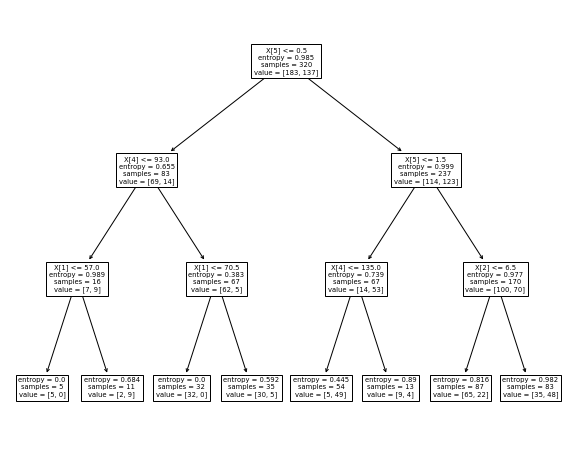

In [22]:
# Plot the Decision tree
plt.rcParams['figure.figsize']= (10,8)
tree.plot_tree(model);

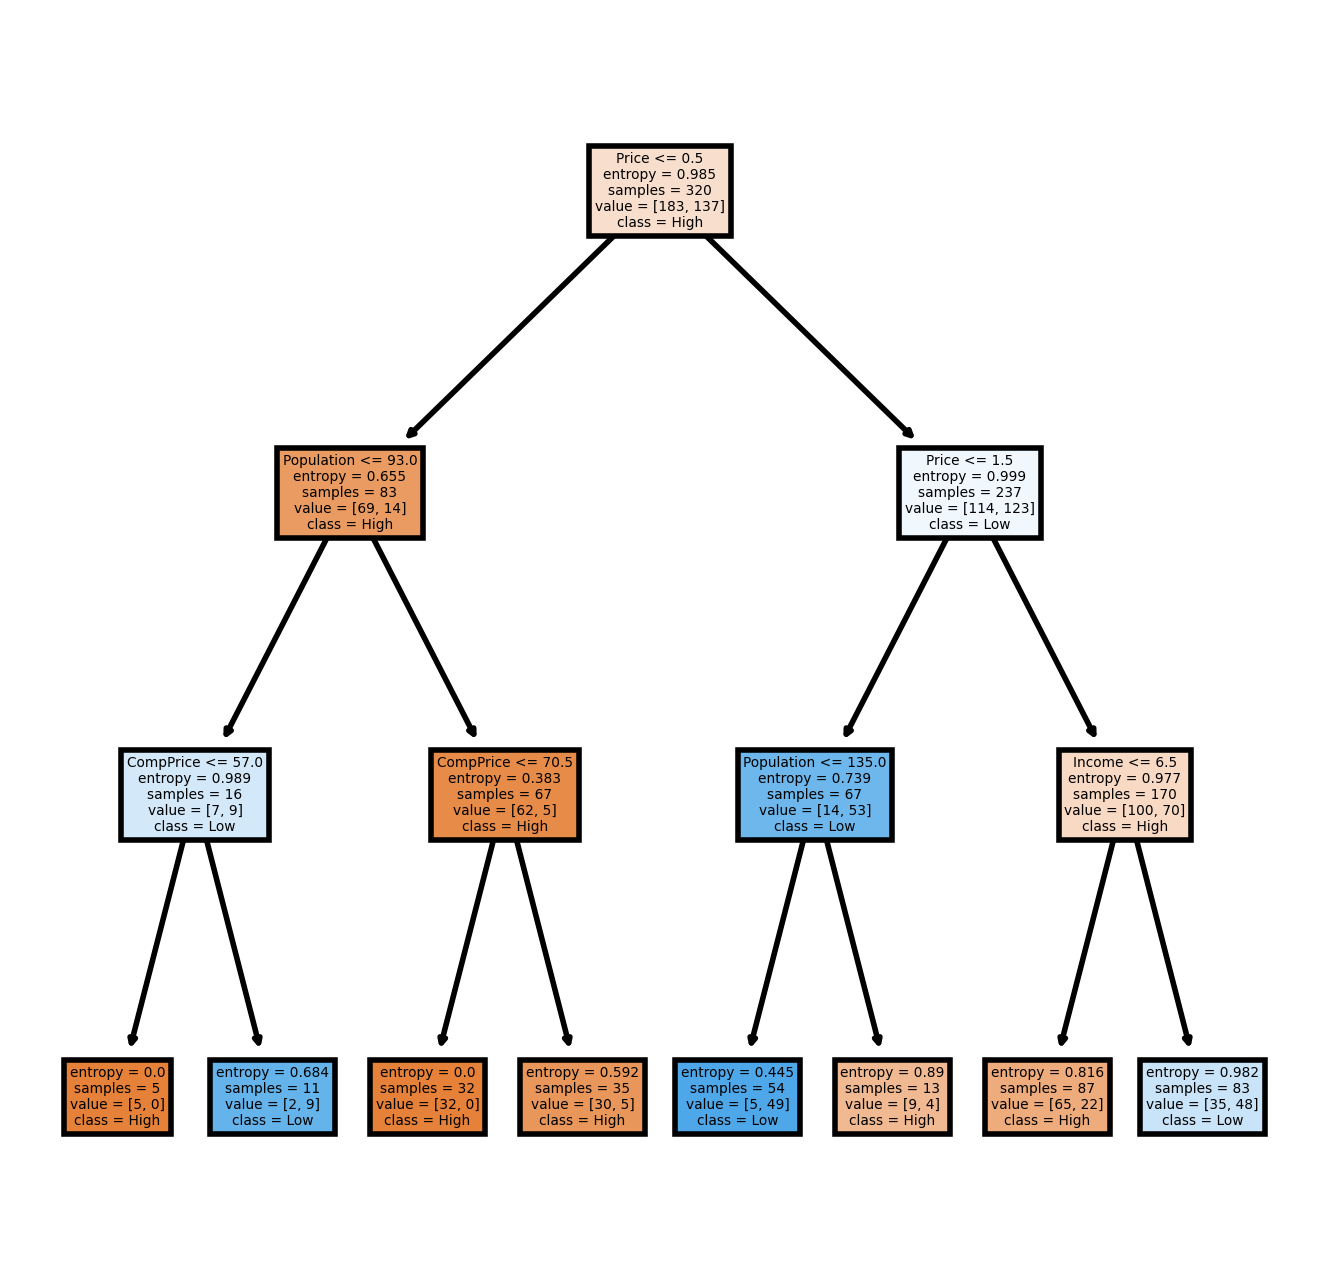

In [23]:
fn=['Sales','CompPrice','Income','Advertising','Population','Price','Age','Education','Urban','US']
cn=['High', 'Low']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=400)
tree.plot_tree(model,
               feature_names = fn, 
               class_names=cn,
               filled = True);

In [24]:
model.fit(x_train, y_train)
model.score(x_train, y_train)

0.771875

Building Decision Tree Classifier (CART) using Gini Criteria

In [25]:
from sklearn.tree import DecisionTreeClassifier
model_gini = DecisionTreeClassifier(criterion = 'gini', max_depth=3)

In [26]:
model_gini.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [27]:
# Prediction and computing the accuracy
pred = model.predict(x_test)
pred

array(['0', '1', '1', '0', '0', '0', '1', '0', '0', '1', '0', '0', '1',
       '1', '1', '0', '1', '0', '0', '0', '1', '0', '0', '1', '1', '0',
       '1', '0', '1', '1', '1', '1', '1', '1', '0', '0', '0', '0', '1',
       '0', '1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0',
       '1', '0', '0', '1', '1', '0', '0', '0', '0', '1', '0', '0', '0',
       '1', '1', '0', '0', '1', '1', '1', '0', '0', '0', '1', '0', '0',
       '1', '0'], dtype=object)

In [28]:
np.mean(pred == y_test)

0.7

 Decision Tree Regression

In [29]:
from sklearn.tree import DecisionTreeRegressor

In [30]:
array = data.values
X = array[:,0:6]
Y = array[:,6]

In [31]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.33, random_state=1)

In [32]:
# Find the accuracy
model.score(X_test, y_test)

0.7196969696969697

## Fraud_Check Data

Q. Use decision trees to prepare a model on fraud data 
treating those who have taxable_income <= 30000 as "Risky" and others are "Good"

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import  DecisionTreeClassifier
from sklearn import tree
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder

In [2]:
# Import Dataset
data = pd.read_csv('E:\Assignment\Assignment 14 - Dicision tree\Fraud_check.csv')
data.head()

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban
0,NO,Single,68833,50047,10,YES
1,YES,Divorced,33700,134075,18,YES
2,NO,Married,36925,160205,30,YES
3,YES,Single,50190,193264,15,YES
4,NO,Married,81002,27533,28,NO


In [3]:
data.describe()

,Taxable.Income,City.Population,Work.Experience
count,600.000000,600.000000,600.000000
mean,55208.375000,108747.368333,15.558333
std,26204.827597,49850.075134,8.842147
min,10003.000000,25779.000000,0.000000
25%,32871.500000,66966.750000,8.000000
50%,55074.500000,106493.500000,15.000000
75%,78611.750000,150114.250000,24.000000
max,99619.000000,199778.000000,30.000000


In [4]:
data.loc[data['Taxable.Income']>=30000, 'Income']='Good'
data.loc[data['Taxable.Income']<=30000, 'Income']='Risky'

In [5]:
data

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban,Income
0,NO,Single,68833,50047,10,YES,Good
1,YES,Divorced,33700,134075,18,YES,Good
2,NO,Married,36925,160205,30,YES,Good
3,YES,Single,50190,193264,15,YES,Good
4,NO,Married,81002,27533,28,NO,Good
...,...,...,...,...,...,...,...
595,YES,Divorced,76340,39492,7,YES,Good
596,YES,Divorced,69967,55369,2,YES,Good
597,NO,Divorced,47334,154058,0,YES,Good
598,YES,Married,98592,180083,17,NO,Good


In [6]:
label_encoder= preprocessing.LabelEncoder()
data['Income']= label_encoder.fit_transform(data['Income'])
data['Undergrad']= label_encoder.fit_transform(data['Undergrad'])
data['Urban']= label_encoder.fit_transform(data['Urban'])
data['Marital.Status']= label_encoder.fit_transform(data['Marital.Status'])

In [7]:
#Droping the Taxable income variable - we taken that as Income description
data.drop(["Taxable.Income"],axis=1,inplace=True)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Undergrad        600 non-null    int32
 1   Marital.Status   600 non-null    int32
 2   City.Population  600 non-null    int64
 3   Work.Experience  600 non-null    int64
 4   Urban            600 non-null    int32
 5   Income           600 non-null    int32
dtypes: int32(4), int64(2)
memory usage: 18.9 KB


In [9]:
data['Income'].value_counts()

0    476
1    124
Name: Income, dtype: int64

In [11]:
#diving data for traing and test
x = data.iloc[:,0:5]
y = data.iloc[:,5]
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state=40)

Building Decision Tree Clasifier using Entropy Criteria¶

In [12]:
model= DecisionTreeClassifier(criterion='entropy', max_depth=3)
model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

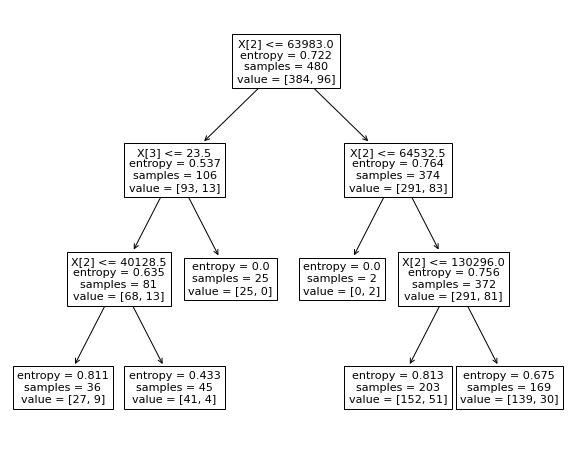

In [13]:
plt.rcParams['figure.figsize']= (10,8)
tree.plot_tree(model);

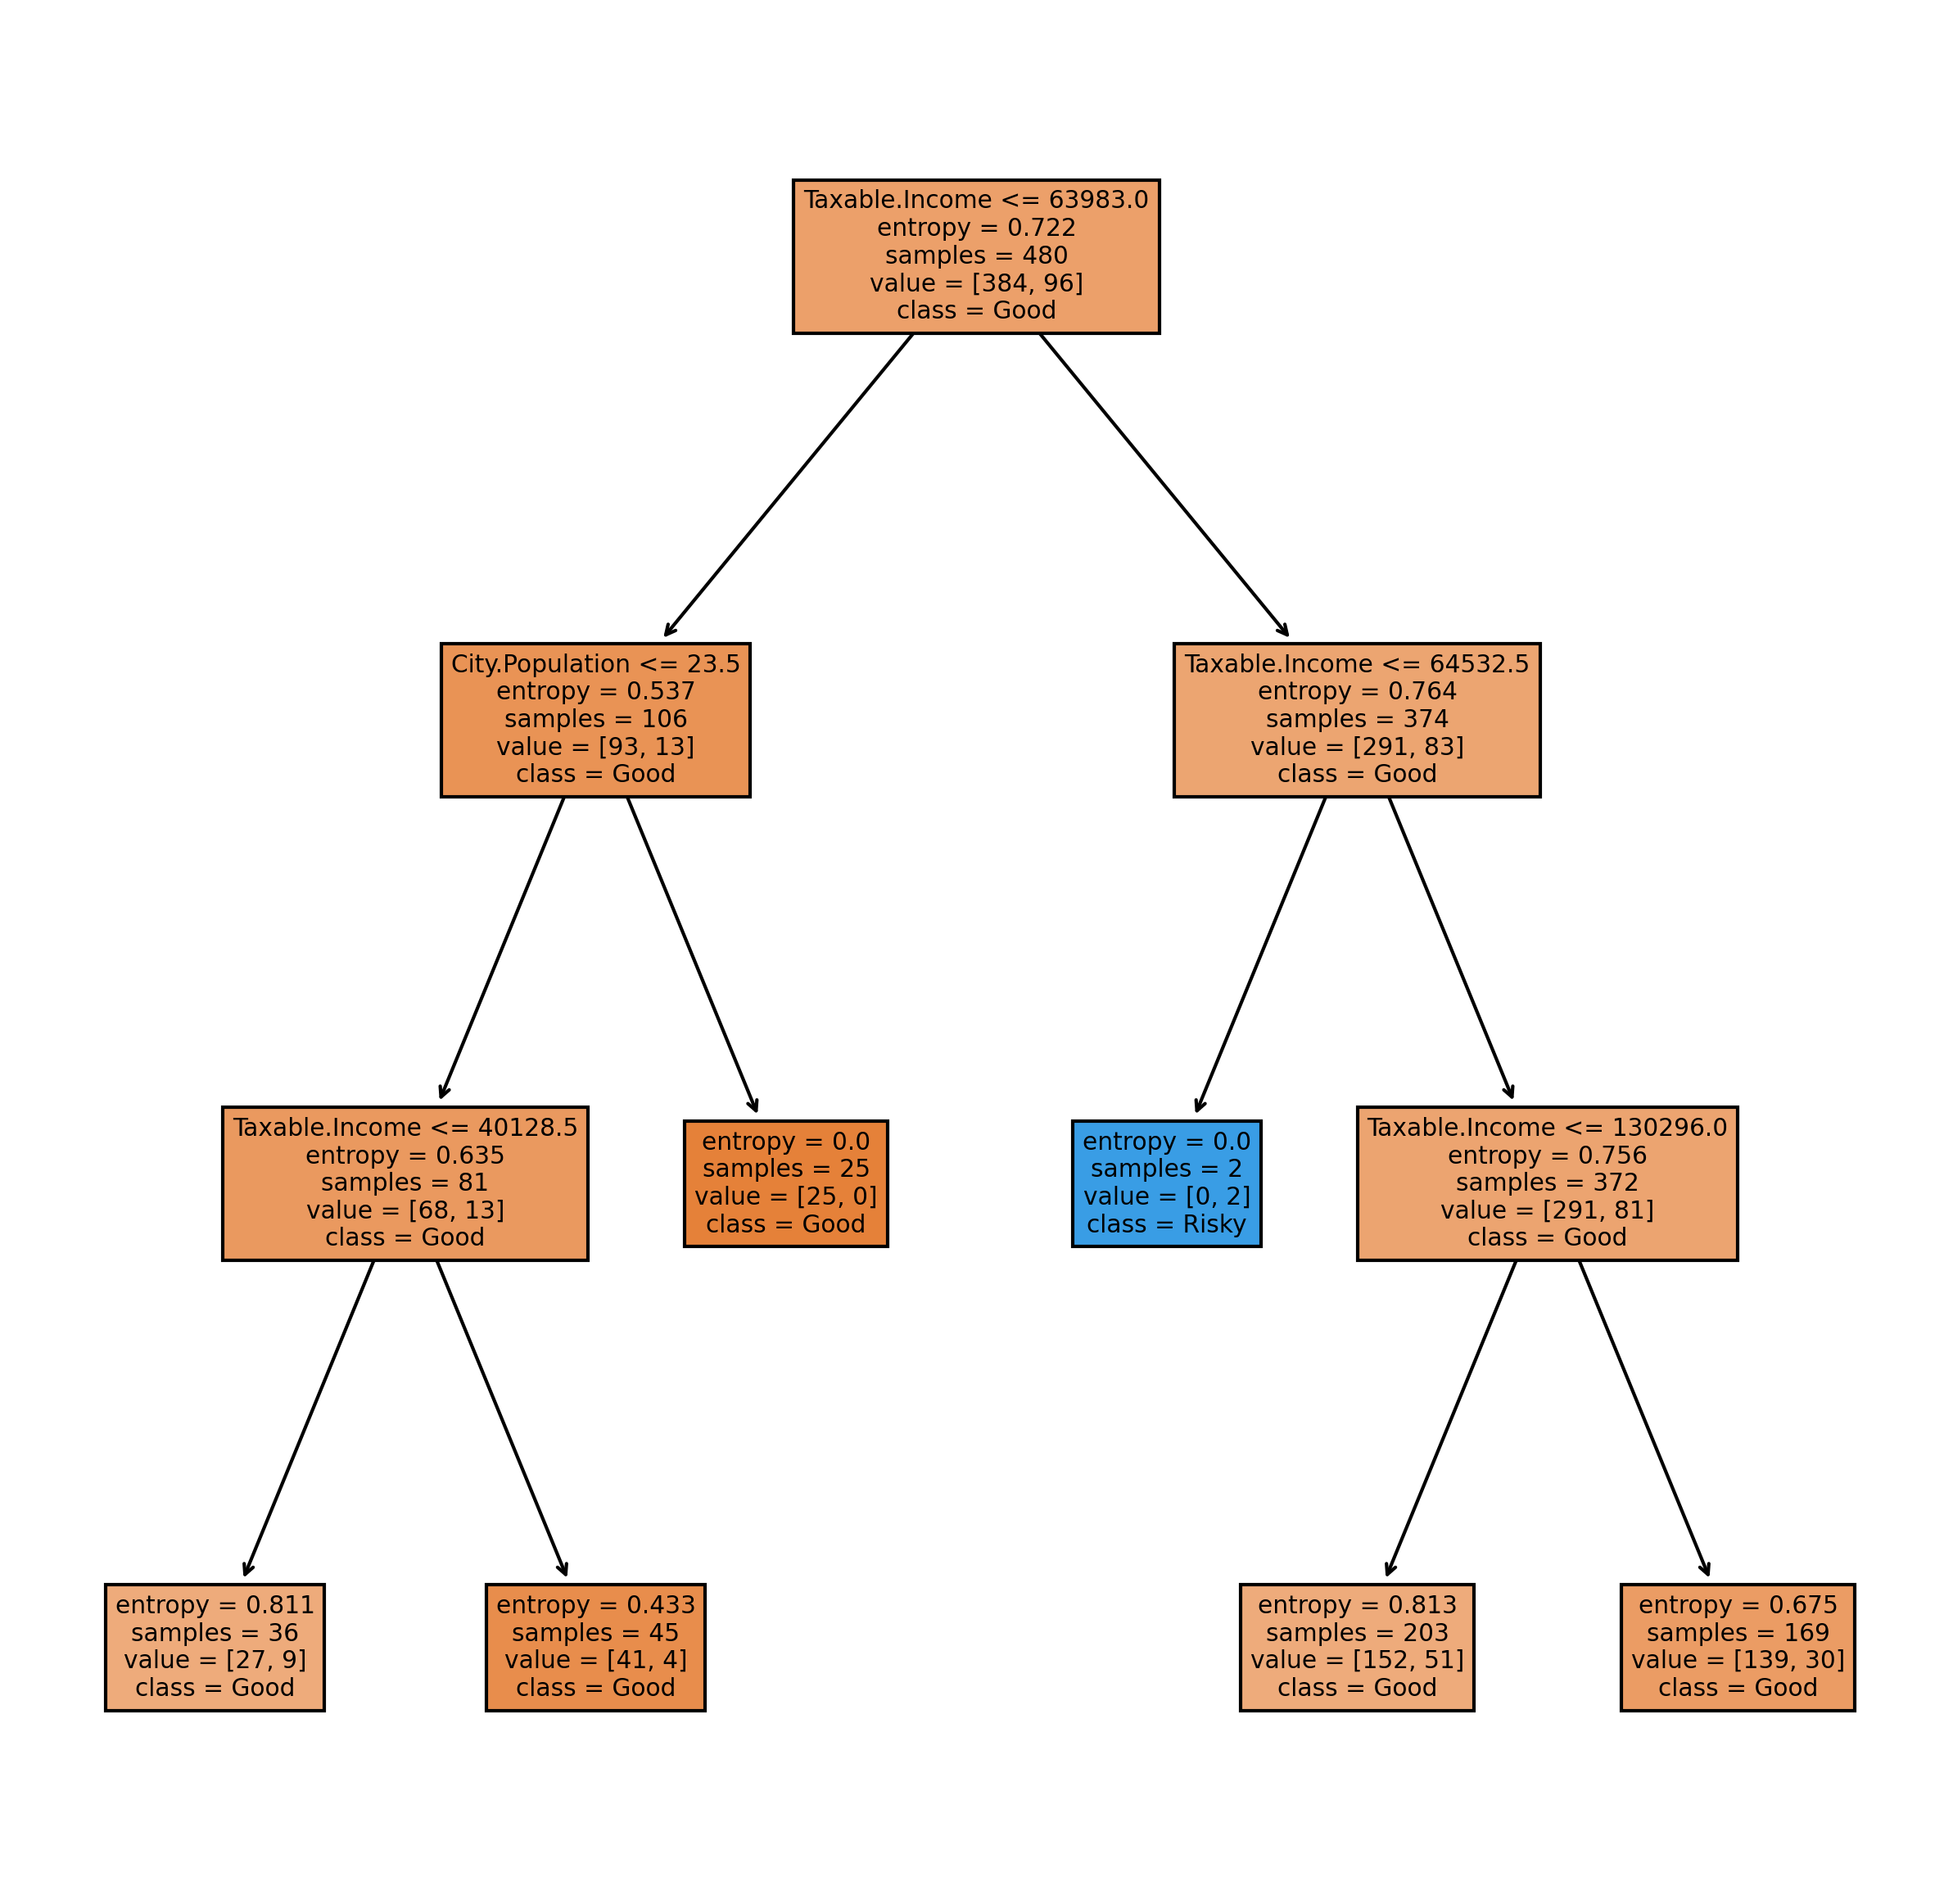

In [14]:
fn=['Undergrad', 'Marital.Status', 'Taxable.Income', 'City.Population',
       'Work.Experience', 'Urban']
cn=['Good','Risky']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (10,10), dpi=300)
tree.plot_tree(model,
               feature_names = fn, 
               class_names=cn,
               filled = True);

In [15]:
model.fit(x_train, y_train)
model.score(x_train, y_train)  #Accuracy = 80.41%

0.8041666666666667

In [16]:
y_pred= model.predict(x_test)

In [17]:
# Here first column is for 'Good' , & second is for 'Risky'
model.predict_proba(x_test)

array([[0.75      , 0.25      ],
       [1.        , 0.        ],
       [0.74876847, 0.25123153],
       [0.82248521, 0.17751479],
       [0.74876847, 0.25123153],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.74876847, 0.25123153],
       [0.91111111, 0.08888889],
       [0.91111111, 0.08888889],
       [0.82248521, 0.17751479],
       [0.75      , 0.25      ],
       [0.82248521, 0.17751479],
       [0.91111111, 0.08888889],
       [0.82248521, 0.17751479],
       [0.82248521, 0.17751479],
       [0.82248521, 0.17751479],
       [0.82248521, 0.17751479],
       [0.74876847, 0.25123153],
       [0.75      , 0.25      ],
       [0.74876847, 0.25123153],
       [0.91111111, 0.08888889],
       [0.91111111, 0.08888889],
       [0.74876847, 0.25123153],
       [0.74876847, 0.25123153],
       [0.74876847, 0.25123153],
       [1.        , 0.        ],
       [0.74876847, 0.25123153],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.

 Building Decision Tree Classifier(CART) using Gini Criteria

In [18]:
from sklearn.tree import DecisionTreeClassifier
model_gini = DecisionTreeClassifier(criterion = 'gini', max_depth=3)

In [19]:
model_gini.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [20]:
# Prediction and computing the accuracy
pred = model.predict(x_test)
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [21]:
np.mean(pred == y_test)  # Accuracy = 76.67%

0.7666666666666667

Decision Tree Regression

In [22]:
from sklearn.tree import DecisionTreeRegressor

In [23]:
array = data.values
X = array[:,0:5]
Y = array[:,5]

In [24]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.33, random_state=1)

In [25]:
# Find the accuracy
model.score(X_test, y_test)   # Accuracy = 79.79%

0.797979797979798